  5%|▍         | 94/2000 [00:00<00:04, 467.78it/s]

  9%|▉         | 188/2000 [00:00<00:03, 467.26it/s]

 14%|█▍        | 282/2000 [00:00<00:03, 466.32it/s]

 19%|█▉        | 376/2000 [00:00<00:03, 466.73it/s]

 24%|██▎       | 470/2000 [00:01<00:03, 465.43it/s]

...

 87%|████████▋ | 1739/2000 [00:03<00:00, 463.29it/s]

 92%|█████████▏| 1833/2000 [00:03<00:00, 463.41it/s]

 96%|█████████▋| 1927/2000 [00:04<00:00, 463.55it/s]

100%|██████████| 2000/2000 [00:04<00:00, 464.69it/s]

torch.Size([2, 640, 853])


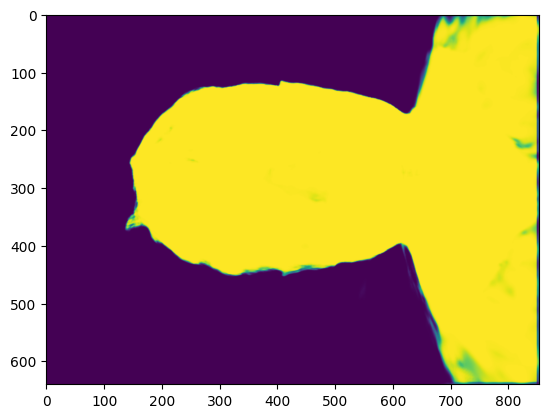

In [256]:
import torch
import matplotlib.pyplot as plt
import scipy
from sklearn import cluster
import numpy as np
import tqdm

feature_map = torch.load("output/segs.pty")
gt_segmask = torch.load("output/gt_segs.pty")


plt.imshow(gt_segmask.cpu().detach().numpy().squeeze() > 1)

class Segmenter(torch.nn.Module):
    def __init__(self, feature_dim, n_classes):
        super().__init__()
        self.W0 = torch.nn.Conv2d(feature_dim, 2, kernel_size=9, padding=4, stride=1).to(feature_map.device)
        self.n_classes = n_classes
    def forward(self, feature_map):
        x = (self.W0(feature_map))
        return x# x.T.reshape((self.n_classes, *feature_map.shape[1:]))
        


segmenter = Segmenter(feature_map.shape[0],2)
optim = torch.optim.AdamW(segmenter.parameters(), lr=1e-3, weight_decay=1e-4)


iterations = 2000
feature_map = torch.log(feature_map)
feature_map = feature_map.detach()
for i in tqdm.tqdm(range(iterations)):
    y = segmenter(feature_map).permute(1,2,0)

    target = torch.zeros_like(y)
    target[gt_segmask.squeeze() == 1, 0]  = 1
    target[gt_segmask.squeeze() > 1, 1]  = 1
    target[gt_segmask.squeeze() == 0, 0]  = 0.5
    target[gt_segmask.squeeze() == 0, 1]  = 0.5


    loss = torch.nn.functional.cross_entropy(y.reshape(-1, y.shape[2]), target.reshape(-1, y.shape[2]))
    loss.backward()
    optim.step()
    optim.zero_grad(True)
    print(f"Loss: {loss.item(): 3.5f}   \r", end="")


with torch.no_grad():
    y = segmenter(feature_map)
    print(y.shape)

test = torch.softmax(y, 0)[1,...]
plt.imshow(test.cpu().detach().numpy())

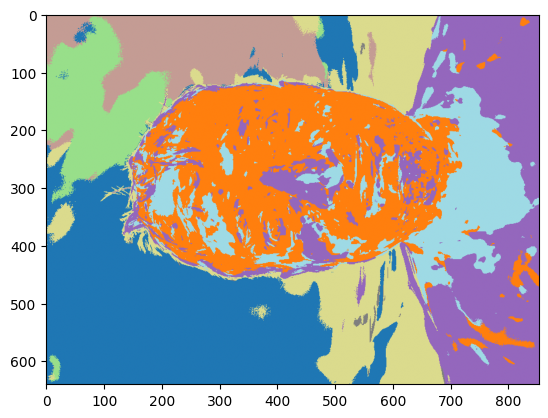

In [268]:
from sklearn import mixture
all_feats = []

for i in range(0, 649, 30):
    feature_map = torch.load(f"/tmp/feats_{i}.pth")
    fmap = torch.log(feature_map.clamp_min(1e-6))

    fmap_np = fmap.cpu().numpy().reshape(fmap.shape[0], -1).T
    all_feats.append(fmap_np)

all_feats = np.concatenate(all_feats, axis=0)

gmm = mixture.GaussianMixture(8)
gmm.fit(all_feats)

# predict on last frame (or any frame)


feature_map = torch.load(f"/tmp/feats_0.pth")
fmap = torch.log(feature_map.clamp_min(1e-6))
fmap_np = fmap.cpu().numpy().reshape(fmap.shape[0], -1).T

clusters = gmm.predict(fmap_np).reshape(feature_map.shape[1:])
plt.imshow(clusters, cmap='tab20')  # good for discrete labels
plt.show()

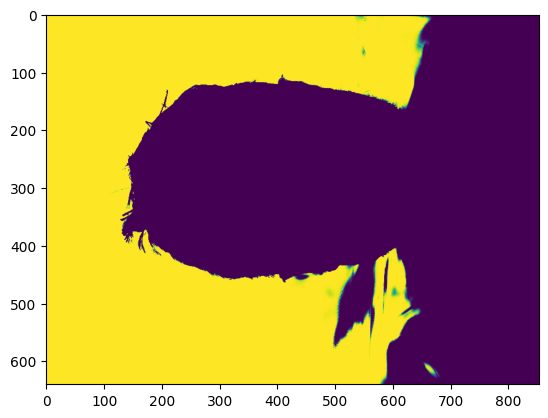

In [224]:
clusters = kmeans.predict_proba(fmap_np).reshape((*feature_map.shape[1:], -1))
plt.imshow(clusters[:,:,0])  
plt.show()